# EDA — NYC Taxi Demand & Congestion Pricing

Reads the processed, cleaned dataset (`data/processed/trips/`) via DuckDB. See `README.md` “ETL Pipeline” section for how this data was produced.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import duckdb

import config
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
con = duckdb.connect(str(config.DUCKDB_PATH), read_only=True)  # notebook only ever reads

con.execute(f"""
    CREATE OR REPLACE TEMP VIEW trips AS
    SELECT * FROM read_parquet('{config.PROCESSED_DIR}/trips/*/*/*.parquet', hive_partitioning=true)
""")

In [3]:
# Smoke test: confirm the view reads correctly before doing any real analysis.
con.execute("SELECT COUNT(*) AS row_count FROM trips").df()

,row_count
0,141606032


In [4]:
con.execute("SELECT * FROM trips LIMIT 5").df()

,PULocationID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,...,pickup_weekday,pickup_is_weekend,tpep_pickup_datetime_utc,tpep_dropoff_datetime_utc,post_congestion_pricing,pickup_borough,pickup_zone_name,pickup_is_crz_zone,pickup_month,pickup_year
0,161,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,141,2,...,1,True,2022-12-31 21:32:10,2022-12-31 21:40:36,False,Manhattan,Midtown Center,True,1,2023
1,236,1,2023-01-20 11:48:19,2023-01-20 12:00:40,1.0,1.40,1.0,N,237,1,...,6,False,2023-01-20 08:48:19,2023-01-20 09:00:40,False,Manhattan,Upper East Side North,False,1,2023
2,43,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,237,1,...,1,True,2022-12-31 21:55:08,2022-12-31 22:01:27,False,Manhattan,Central Park,False,1,2023
3,90,2,2023-01-20 11:22:37,2023-01-20 11:31:57,1.0,0.80,1.0,N,113,2,...,6,False,2023-01-20 08:22:37,2023-01-20 08:31:57,False,Manhattan,Flatiron,True,1,2023
4,48,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,238,1,...,1,True,2022-12-31 21:25:04,2022-12-31 21:37:49,False,Manhattan,Clinton East,True,1,2023


## Peak pickup hours

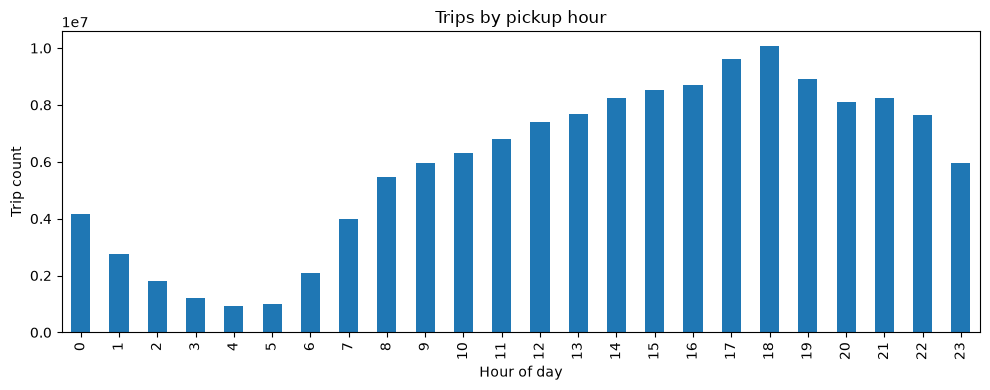

In [5]:
hourly = con.execute("""
    SELECT pickup_hour, COUNT(*) AS trips
    FROM trips
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""").df()

hourly.plot(x="pickup_hour", y="trips", kind="bar", figsize=(10, 4), legend=False, title="Trips by pickup hour")
plt.xlabel("Hour of day")
plt.ylabel("Trip count")
plt.tight_layout()
plt.show()

## Peak weekdays

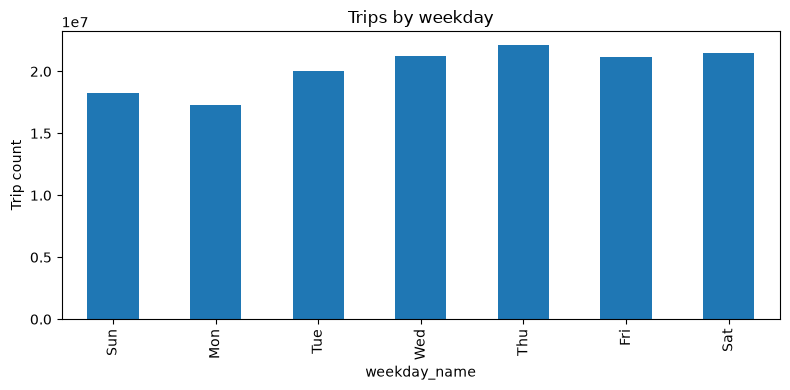

In [6]:
weekday_names = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}

weekday_df = con.execute("""
    SELECT pickup_weekday, COUNT(*) AS trips
    FROM trips
    GROUP BY pickup_weekday
    ORDER BY pickup_weekday
""").df()
weekday_df["weekday_name"] = weekday_df["pickup_weekday"].map(weekday_names)

weekday_df.plot(x="weekday_name", y="trips", kind="bar", figsize=(8, 4), legend=False, title="Trips by weekday")
plt.ylabel("Trip count")
plt.tight_layout()
plt.show()

## Top pickup zones

In [7]:
top_by_count = con.execute("""
    SELECT pickup_zone_name, pickup_borough, COUNT(*) AS trips
    FROM trips
    GROUP BY pickup_zone_name, pickup_borough
    ORDER BY trips DESC
    LIMIT 10
""").df()
print("Top 10 zones by trip count:")
display(top_by_count)

top_by_revenue = con.execute("""
    SELECT pickup_zone_name, pickup_borough, ROUND(SUM(total_amount), 2) AS revenue
    FROM trips
    GROUP BY pickup_zone_name, pickup_borough
    ORDER BY revenue DESC
    LIMIT 10
""").df()
print("Top 10 zones by revenue:")
display(top_by_revenue)

Top 10 zones by trip count:


,pickup_zone_name,pickup_borough,trips
0,Upper East Side South,Manhattan,6568027
1,Midtown Center,Manhattan,6384872
2,JFK Airport,Queens,6216364
3,Upper East Side North,Manhattan,5873605
4,Midtown East,Manhattan,4745401
5,Penn Station/Madison Sq West,Manhattan,4650463
6,Times Sq/Theatre District,Manhattan,4556376
7,Lincoln Square East,Manhattan,4407338
8,LaGuardia Airport,Queens,4200799
9,Murray Hill,Manhattan,3976585


Top 10 zones by revenue:


,pickup_zone_name,pickup_borough,revenue
0,JFK Airport,Queens,4.921915e+08
1,LaGuardia Airport,Queens,2.836675e+08
2,Midtown Center,Manhattan,1.645587e+08
3,Upper East Side South,Manhattan,1.387595e+08
4,Times Sq/Theatre District,Manhattan,1.322480e+08
5,Upper East Side North,Manhattan,1.264931e+08
6,Penn Station/Madison Sq West,Manhattan,1.190582e+08
7,Midtown East,Manhattan,1.181796e+08
8,Lincoln Square East,Manhattan,9.989680e+07
9,Midtown North,Manhattan,9.910549e+07


## Revenue by borough

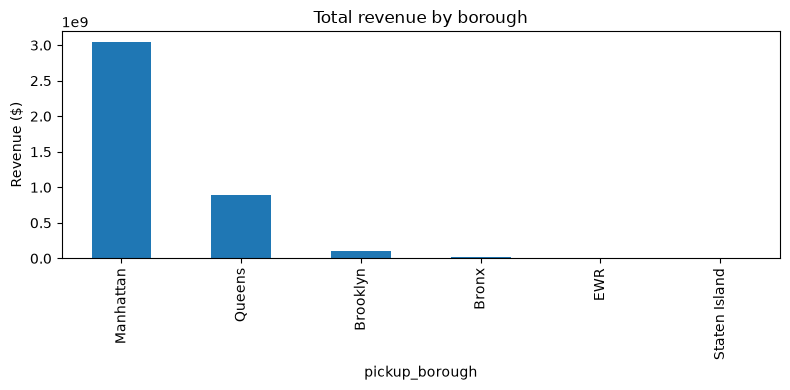

,pickup_borough,revenue,trips
0,Manhattan,3.042578e+09,124619607
1,Queens,8.870329e+08,13057326
2,Brooklyn,1.026752e+08,3175831
3,Bronx,2.470463e+07,725231
4,EWR,1.871550e+06,17930
5,Staten Island,5.180308e+05,10107


In [8]:
borough_rev = con.execute("""
    SELECT pickup_borough, ROUND(SUM(total_amount), 2) AS revenue, COUNT(*) AS trips
    FROM trips
    GROUP BY pickup_borough
    ORDER BY revenue DESC
""").df()

borough_rev.plot(x="pickup_borough", y="revenue", kind="bar", figsize=(8, 4), legend=False, title="Total revenue by borough")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()
borough_rev

## Average trip distance

In [9]:
overall_avg = con.execute("SELECT ROUND(AVG(trip_distance), 2) AS avg_trip_distance_mi FROM trips").df()
print("Overall average trip distance (mi):", overall_avg.iloc[0, 0])

dist_by_borough = con.execute("""
    SELECT pickup_borough, ROUND(AVG(trip_distance), 2) AS avg_trip_distance_mi
    FROM trips
    GROUP BY pickup_borough
    ORDER BY avg_trip_distance_mi DESC
""").df()
dist_by_borough

Overall average trip distance (mi): 5.21


,pickup_borough,avg_trip_distance_mi
0,Staten Island,45.93
1,Bronx,30.82
2,Brooklyn,19.35
3,Queens,13.33
4,Manhattan,3.85
5,EWR,0.80


## Seasonal trends

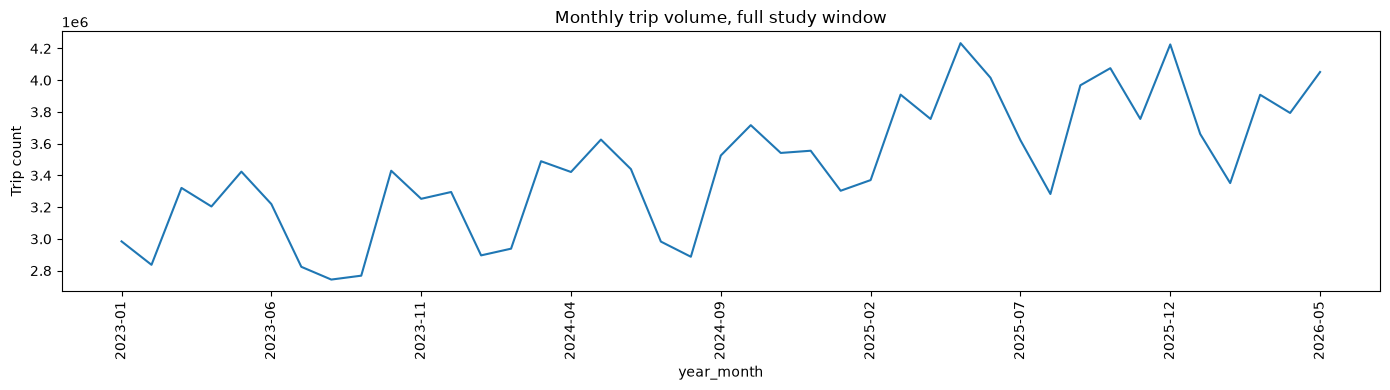

In [10]:
monthly = con.execute("""
    SELECT pickup_year, pickup_month, COUNT(*) AS trips
    FROM trips
    GROUP BY pickup_year, pickup_month
    ORDER BY pickup_year, pickup_month
""").df()
monthly["year_month"] = monthly["pickup_year"].astype(str) + "-" + monthly["pickup_month"].astype(str).str.zfill(2)

monthly.plot(x="year_month", y="trips", kind="line", figsize=(14, 4), legend=False, title="Monthly trip volume, full study window")
plt.ylabel("Trip count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Airport demand

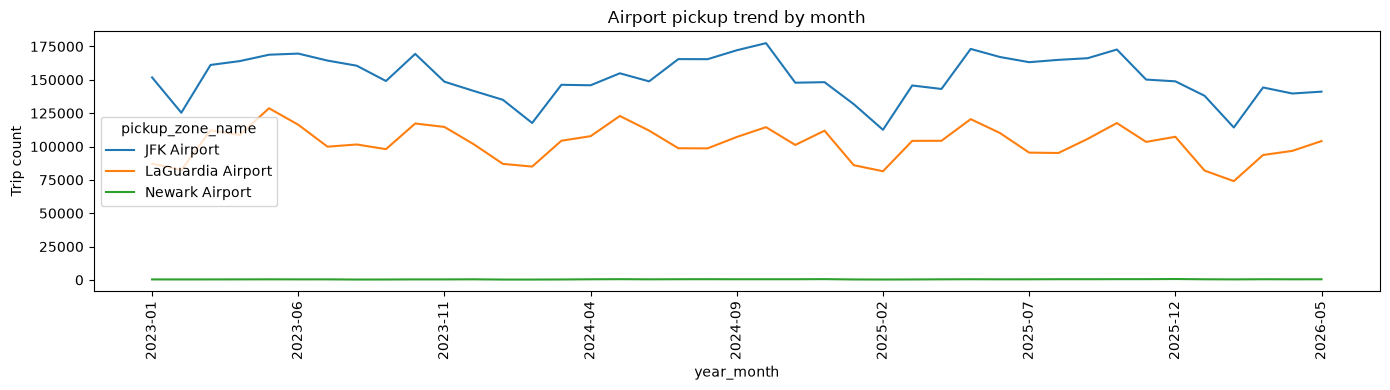

In [11]:
airport_trend = con.execute("""
    SELECT pickup_year, pickup_month, pickup_zone_name, COUNT(*) AS trips
    FROM trips
    WHERE pickup_zone_name IN ('JFK Airport', 'LaGuardia Airport', 'Newark Airport')
    GROUP BY pickup_year, pickup_month, pickup_zone_name
    ORDER BY pickup_year, pickup_month
""").df()
airport_trend["year_month"] = airport_trend["pickup_year"].astype(str) + "-" + airport_trend["pickup_month"].astype(str).str.zfill(2)

pivot = airport_trend.pivot(index="year_month", columns="pickup_zone_name", values="trips")
pivot.plot(figsize=(14, 4), title="Airport pickup trend by month")
plt.ylabel("Trip count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Weather data

In [12]:
weather_df = con.execute(f"SELECT * FROM read_parquet('{config.WEATHER_PATH}')").df()
print("weather rows:", len(weather_df), "range:", weather_df["weather_datetime"].min(), "to", weather_df["weather_datetime"].max())
weather_df.head()

weather rows: 29928 range: 2023-01-01 00:00:00 to 2026-05-31 23:00:00


,weather_datetime,temperature_2m,precipitation,snowfall
0,2023-01-01 00:00:00,10.9,1.0,0.0
1,2023-01-01 01:00:00,10.6,1.0,0.0
2,2023-01-01 02:00:00,10.6,0.1,0.0
3,2023-01-01 03:00:00,10.5,0.0,0.0
4,2023-01-01 04:00:00,9.8,0.0,0.0


## CRZ vs. non-CRZ trend, pre/post Jan 5 2025

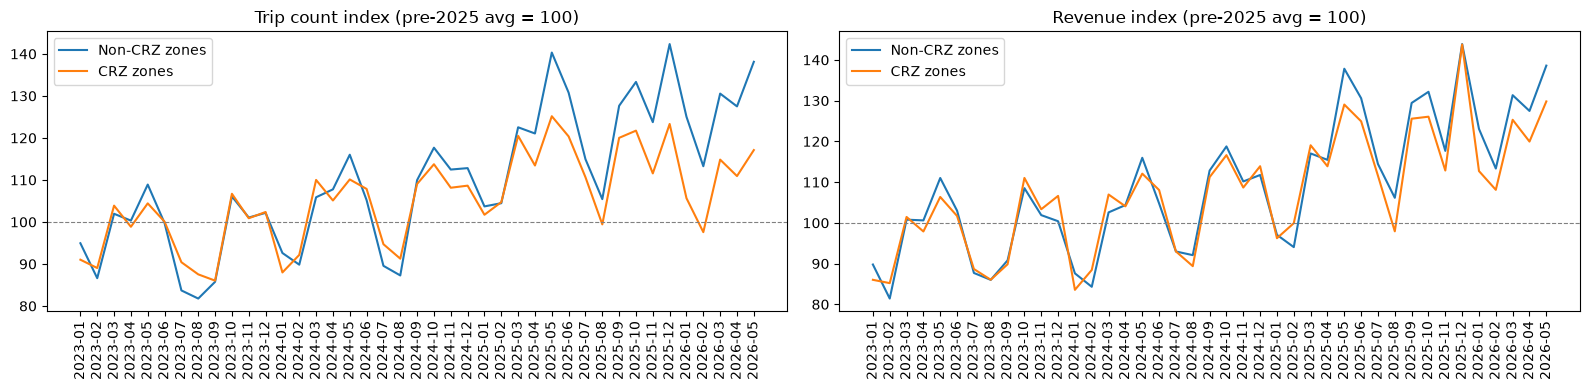

In [13]:
monthly_crz = con.execute("""
    SELECT pickup_year, pickup_month, pickup_is_crz_zone,
           COUNT(*) AS trips, ROUND(SUM(total_amount), 2) AS revenue
    FROM trips
    GROUP BY pickup_year, pickup_month, pickup_is_crz_zone
    ORDER BY pickup_year, pickup_month
""").df()
monthly_crz["year_month"] = monthly_crz["pickup_year"].astype(str) + "-" + monthly_crz["pickup_month"].astype(str).str.zfill(2)

pre = monthly_crz[monthly_crz["pickup_year"] < 2025]
baseline = pre.groupby("pickup_is_crz_zone")[["trips", "revenue"]].mean()
monthly_crz = monthly_crz.merge(baseline, on="pickup_is_crz_zone", suffixes=("", "_baseline"))
monthly_crz["trips_index"] = 100 * monthly_crz["trips"] / monthly_crz["trips_baseline"]
monthly_crz["revenue_index"] = 100 * monthly_crz["revenue"] / monthly_crz["revenue_baseline"]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for is_crz, group in monthly_crz.groupby("pickup_is_crz_zone"):
    label = "CRZ zones" if is_crz else "Non-CRZ zones"
    axes[0].plot(group["year_month"], group["trips_index"], label=label)
    axes[1].plot(group["year_month"], group["revenue_index"], label=label)
axes[0].set_title("Trip count index (pre-2025 avg = 100)")
axes[1].set_title("Revenue index (pre-2025 avg = 100)")
for ax in axes:
    ax.axhline(100, color="gray", linewidth=0.8, linestyle="--")
    ax.tick_params(axis="x", rotation=90)
    ax.legend()
plt.tight_layout()
plt.show()

# NOTE: this is descriptive, not causal -- no parallel-trends check or control-group
# matching yet. That belongs to the later causal pillar''s proper DiD design. What this
# does show: non-CRZ zones grew faster than CRZ zones after the cutoff (e.g. Dec 2025:
# ~142 vs ~123), and the gap widens through 2025-2026 in a way it wasn'' t doing in 2024.

## Spatial displacement: zones just outside the CRZ boundary

Uses `crz_overlap_fraction` from `enrich_trips.compute_crz_zone_flags()` -- zones with *some* geometric overlap with the CRZ but not majority overlap (so not classified `is_crz_zone`). These are the zones that actually border the tolled area, not just any non-CRZ zone.

boundary-adjacent zones: [12, 43, 140, 141, 142, 143, 237]


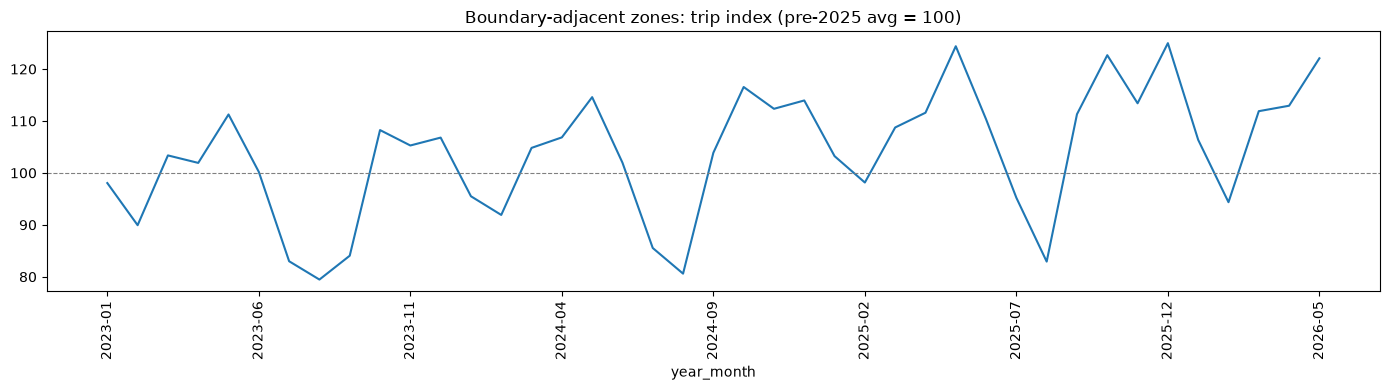

In [14]:
from cleaning.enrich_trips import compute_crz_zone_flags

flags = compute_crz_zone_flags()
boundary_ids = flags[(flags["crz_overlap_fraction"] > 0) & (flags["crz_overlap_fraction"] <= 0.5)]["PULocationID"].tolist()
print("boundary-adjacent zones:", boundary_ids)

ids_str = ",".join(str(i) for i in boundary_ids)
boundary_monthly = con.execute(f"""
    SELECT pickup_year, pickup_month, COUNT(*) AS trips
    FROM trips
    WHERE PULocationID IN ({ids_str})
    GROUP BY pickup_year, pickup_month
    ORDER BY pickup_year, pickup_month
""").df()
boundary_monthly["year_month"] = boundary_monthly["pickup_year"].astype(str) + "-" + boundary_monthly["pickup_month"].astype(str).str.zfill(2)
pre_avg = boundary_monthly[boundary_monthly["pickup_year"] < 2025]["trips"].mean()
boundary_monthly["index"] = 100 * boundary_monthly["trips"] / pre_avg

boundary_monthly.plot(x="year_month", y="index", figsize=(14, 4), legend=False, title="Boundary-adjacent zones: trip index (pre-2025 avg = 100)")
plt.axhline(100, color="gray", linewidth=0.8, linestyle="--")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Finding: this index (roughly 95-125 post-cutoff) tracks in the same range as the general
# non-CRZ trend above -- no distinct outsized spike specific to the boundary zones beyond
# what non-CRZ zones show generally. Doesn't support a strong, distinct displacement signal.

## Substitution check

In [ ]:
# 1. Trip distance/duration for CRZ-related trips (pickup OR dropoff in the CRZ), pre vs post.
# Needs a dropoff-side CRZ flag too, which the main pipeline doesn't build (it's pickup-grain
# by design) -- computed ad hoc here via the same compute_crz_zone_flags(), not persisted.
dropoff_flags = flags[["PULocationID", "is_crz_zone"]].rename(
    columns={"PULocationID": "DOLocationID", "is_crz_zone": "dropoff_is_crz_zone"}
)
con.register("dropoff_crz", dropoff_flags)

distance_duration = con.execute("""
    SELECT
        post_congestion_pricing,
        ROUND(AVG(t.trip_distance), 3) AS avg_distance_mi,
        ROUND(AVG(EPOCH(t.tpep_dropoff_datetime) - EPOCH(t.tpep_pickup_datetime)) / 60, 2) AS avg_duration_min,
        COUNT(*) AS trips
    FROM trips t
    LEFT JOIN dropoff_crz d ON t.DOLocationID = d.DOLocationID
    WHERE t.pickup_is_crz_zone = true OR d.dropoff_is_crz_zone = true
    GROUP BY post_congestion_pricing
""").df()
print("CRZ-related trips (pickup or dropoff in CRZ), pre vs post:")
display(distance_duration)
# Finding: avg distance for CRZ-related trips rose ~4.04 -> ~5.30 mi (+31%) post-cutoff, while
# duration stayed roughly flat -- consistent with fewer short "just crossing the boundary"
# hops surviving the toll, leaving a longer-distance mix of remaining CRZ-related trips.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CRZ-related trips (pickup or dropoff in CRZ), pre vs post:


,post_congestion_pricing,avg_distance_mi,avg_duration_min,trips
0,True,5.295,17.41,45589448
1,False,4.044,17.87,57198042


### Outer-borough trend, checked against the general non-CRZ baseline

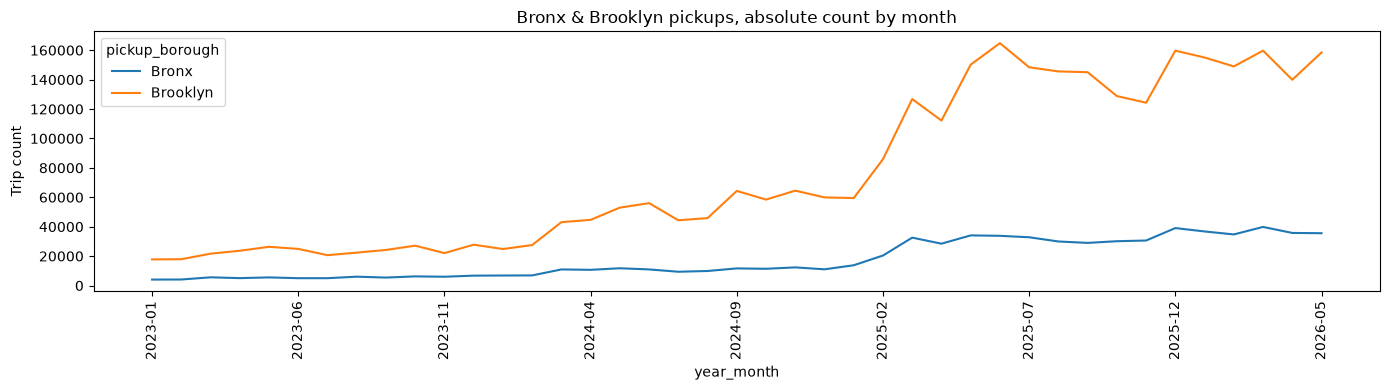

In [ ]:
borough_monthly = con.execute("""
    SELECT pickup_year, pickup_month, pickup_borough, COUNT(*) AS trips
    FROM trips
    WHERE pickup_borough != 'Manhattan'
    GROUP BY pickup_year, pickup_month, pickup_borough
    ORDER BY pickup_year, pickup_month
""").df()
borough_monthly["year_month"] = borough_monthly["pickup_year"].astype(str) + "-" + borough_monthly["pickup_month"].astype(str).str.zfill(2)

pivot_abs = borough_monthly.pivot(index="year_month", columns="pickup_borough", values="trips")
pivot_abs[["Bronx", "Brooklyn"]].plot(figsize=(14, 4), title="Bronx & Brooklyn pickups, absolute count by month")
plt.ylabel("Trip count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# IMPORTANT: an indexed-to-baseline view makes Bronx/Brooklyn look like they exploded to
# 350-500% post-cutoff. Plotting the absolute series (above) shows why that's misleading:
# both have been climbing steadily since 2023 (Bronx Jan: 4,045 -> 6,801 -> 13,770 -> 36,758
# across Jan 2023/24/25/26), with no visible kink right at the Jan 2025 cutoff. This is a
# pre-existing secular trend, not a congestion-pricing substitution effect -- a good concrete
# example of why the later causal pillar needs a proper trend-break/DiD design rather than a
# naive pre/post average, which would badly overstate this as a policy effect.

## Weather elasticity of demand, inside vs. outside the CRZ

In [17]:
hourly = con.execute("""
    SELECT date_trunc('hour', t.tpep_pickup_datetime) AS hr,
           EXTRACT(hour FROM t.tpep_pickup_datetime) AS hour_of_day,
           t.pickup_is_crz_zone, COUNT(*) AS trips
    FROM trips t
    GROUP BY hr, hour_of_day, t.pickup_is_crz_zone
""").df()

joined = hourly.merge(weather_df, left_on="hr", right_on="weather_datetime", how="inner")

# Raw correlation is confounded by the dominant hour-of-day pattern (huge swings between
# 3am and 6pm regardless of weather), so de-mean within (hour_of_day, crz_group) first.
joined["trips_dev"] = joined.groupby(["hour_of_day", "pickup_is_crz_zone"])["trips"].transform(lambda x: x - x.mean())

elasticity = joined.groupby("pickup_is_crz_zone").apply(
    lambda g: pd.Series({
        "corr_precipitation": g["trips_dev"].corr(g["precipitation"]),
        "corr_temperature": g["trips_dev"].corr(g["temperature_2m"]),
        "corr_snowfall": g["trips_dev"].corr(g["snowfall"]),
    }),
    include_groups=False,
)
elasticity
# Finding: all correlations stay under 0.08 in absolute value for both groups, even after
# removing the hour-of-day confound -- weather shows no meaningful relationship with trip
# count here, and no notable difference between CRZ and non-CRZ zones. Plausible reasons:
# a fixed number of cabs may mean rain affects wait time/availability rather than completed
# trip counts, and/or the effect is non-linear (only extreme weather matters) rather than
# linear-correlational.

,corr_precipitation,corr_temperature,corr_snowfall
pickup_is_crz_zone,,,
False,-0.016536,-0.073418,-0.072651
True,0.004169,-0.011415,-0.053227
